# Cluster Quilting: Spectral Clustering on Patchwork Data

Implementation of Algorithm 1 from Zheng, Chang & Allen (2024) — *Cluster Quilting: Spectral Clustering for Patchwork Learning*.

**Steps:**
1. Load patches generated by `generate_quilt.ipynb`
2. Order patches via greedy forward search (maximize sample overlap)
3. Patchwise SVD → align sample-space singular vectors (U) across overlapping samples
4. k-means on the quilted sample embedding
5. Evaluate clustering against true valence labels

In [1]:
import numpy as np
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

## 1. Load Patches

In [2]:
# Load full data to use as X_full for the quilting pipeline
df = pd.read_csv('trialdf_24sessions.csv', index_col=0)
meta_cols = ['valence', 'airstart', 'sucstart', 'ms_id', 'condition', 'inj_site', 'ms_n']
feature_cols = [c for c in df.columns if c not in meta_cols]
df = df.loc[~df['valence'].str.contains('CS', na=False)]
thresh = 0.05 * len(df)
feature_cols = [c for c in feature_cols if df[c].isna().sum() <= thresh]
df = df[feature_cols + meta_cols].dropna()

valence_global = df['valence'].values
X_full = StandardScaler().fit_transform(df[feature_cols].values)
N_total, P_total = X_full.shape

# Load patches (default 3-patch config from generate_quilt.ipynb)
patch_dir = Path('patches/raw')
patch_files = sorted(patch_dir.glob('patch_*.npz'))

patches = []
for f in patch_files:
    p = np.load(f, allow_pickle=True)
    patches.append({
        'data': p['data'],
        'row_idx': p['row_idx'],
        'col_idx': p['col_idx'],
        'valence': p['valence'],
    })

n_patches = len(patches)
print(f'Data: {N_total} samples x {P_total} features')
print(f'Loaded {n_patches} patches from {patch_dir}')
for i, p in enumerate(patches):
    print(f'  Patch {i}: {p["data"].shape[0]} samples x {p["data"].shape[1]} features, '
          f'rows [{p["row_idx"][0]}–{p["row_idx"][-1]}], '
          f'cols [{p["col_idx"][0]}–{p["col_idx"][-1]}]')

# Show sample overlaps
for i in range(n_patches - 1):
    ri = set(patches[i]['row_idx'].tolist())
    ri1 = set(patches[i + 1]['row_idx'].tolist())
    print(f'  Sample overlap {i}<->{i+1}: {len(ri & ri1)}')

Data: 129603 samples x 121 features
Loaded 3 patches from patches/raw
  Patch 0: 58059 samples x 39 features, rows [0–58058], cols [45–83]
  Patch 1: 77376 samples x 37 features, rows [31945–109320], cols [84–120]
  Patch 2: 49731 samples x 45 features, rows [79872–129602], cols [0–44]
  Sample overlap 0<->1: 26114
  Sample overlap 1<->2: 29449


## 2. Patch Ordering (Algorithm 2 — Greedy Forward Search)

Order patches to maximize overlapping signal at each merge step.  
Score function: $s(k, I) = |I_k \cap I|$ — number of shared **samples** (rows).

In [3]:
def greedy_patch_ordering(patches):
    """Algorithm 2: Forward search for patch ordering.
    
    Uses sample (row) overlap size as the score function: s(k, I) = |I_k ∩ I|.
    """
    M = len(patches)
    row_sets = [set(p['row_idx'].tolist()) for p in patches]
    
    # Find the initial pair with maximum sample overlap
    best_score = -1
    best_pair = (0, 1)
    for i in range(M):
        for j in range(M):
            if i == j:
                continue
            score = len(row_sets[i] & row_sets[j])
            if score > best_score:
                best_score = score
                best_pair = (i, j)
    
    ordering = [best_pair[0], best_pair[1]]
    used = set(ordering)
    accumulated_rows = row_sets[best_pair[0]] | row_sets[best_pair[1]]
    
    # Greedily add remaining patches
    for _ in range(2, M):
        best_next = -1
        best_s = -1
        for j in range(M):
            if j in used:
                continue
            s = len(row_sets[j] & accumulated_rows)
            if s > best_s:
                best_s = s
                best_next = j
        ordering.append(best_next)
        used.add(best_next)
        accumulated_rows |= row_sets[best_next]
    
    return ordering

ordering = greedy_patch_ordering(patches)
print(f'Patch ordering: {ordering}')

# Show sample overlaps in the chosen order
accumulated = set(patches[ordering[0]]['row_idx'].tolist())
for k in range(1, n_patches):
    idx = ordering[k]
    current_rows = set(patches[idx]['row_idx'].tolist())
    overlap = len(current_rows & accumulated)
    print(f'  Step {k}: merge patch {idx}, sample overlap = {overlap} rows')
    accumulated |= current_rows

Patch ordering: [1, 2, 0]
  Step 1: merge patch 2, sample overlap = 29449 rows
  Step 2: merge patch 0, sample overlap = 26114 rows


## 3. Cluster Quilting (Algorithm 1)

Patches have **overlapping samples** and **(mostly) disjoint features**, matching
the paper's convention.

- For each patch $X_m$, compute rank-$r$ SVD: $X_m = U_m \Sigma_m V_m^\top$
- Align $U_m$ (sample loadings) across overlapping rows via least-squares
- Accumulate $V_m \Sigma_m$ (feature loadings) with inverse alignment transform
- k-means on the quilted sample embedding $\tilde{U}$

In [4]:
def cluster_quilting(patches, X_full, ordering, r, K):
    """Algorithm 1: Cluster Quilting with overlapping samples.
    
    Parameters
    ----------
    patches : list of dict
        Each dict has 'row_idx', 'col_idx' (data is sliced from X_full).
    X_full : ndarray (N, P)
        Full scaled data matrix.
    ordering : list of int
        Patch indices in merge order.
    r : int
        Rank for truncated SVD.
    K : int
        Number of clusters.
    
    Returns
    -------
    labels : ndarray (N,) — cluster assignments
    U_tilde : ndarray (N, r) — quilted sample embedding
    """
    N, P = X_full.shape
    U_tilde = np.zeros((N, r))
    V_tilde = np.zeros((P, r))
    covered_rows = set()
    
    # --- First patch ---
    m0 = ordering[0]
    row_idx = patches[m0]['row_idx']
    col_idx = patches[m0]['col_idx']
    X_m = X_full[np.ix_(row_idx, col_idx)]
    
    U, S, Vt = np.linalg.svd(X_m, full_matrices=False)
    U_r, S_r, V_r = U[:, :r], S[:r], Vt[:r, :].T
    
    U_tilde[row_idx, :] = U_r
    V_tilde[col_idx, :] = V_r * S_r[np.newaxis, :]
    covered_rows.update(row_idx.tolist())
    
    # --- Subsequent patches: align via overlapping samples ---
    for step in range(1, len(ordering)):
        m = ordering[step]
        row_idx = patches[m]['row_idx']
        col_idx = patches[m]['col_idx']
        X_m = X_full[np.ix_(row_idx, col_idx)]
        
        U, S, Vt = np.linalg.svd(X_m, full_matrices=False)
        U_r, S_r, V_r = U[:, :r], S[:r], Vt[:r, :].T
        
        current_rows = set(row_idx.tolist())
        overlap_global = sorted(current_rows & covered_rows)
        
        if len(overlap_global) < r:
            print(f'  Warning: patch {m} has only {len(overlap_global)} '
                  f'overlapping samples (need >= {r})')
            U_tilde[row_idx, :] = U_r
            V_tilde[col_idx, :] = V_r * S_r[np.newaxis, :]
            covered_rows.update(current_rows)
            continue
        
        # Map global row indices to local
        row_list = row_idx.tolist()
        g2l = {g: l for l, g in enumerate(row_list)}
        local_overlap = [g2l[g] for g in overlap_global]
        
        # Align: U_m[overlap] @ G ≈ U_tilde[overlap]
        U_m_ov = U_r[local_overlap, :]
        U_tilde_ov = U_tilde[overlap_global, :]
        G, _, _, _ = np.linalg.lstsq(U_m_ov, U_tilde_ov, rcond=None)
        
        # Assign new (non-overlap) samples
        new_global = sorted(current_rows - covered_rows)
        if new_global:
            new_local = [g2l[g] for g in new_global]
            U_tilde[new_global, :] = U_r[new_local, :] @ G
        
        # Transform feature vectors
        G_inv_T = np.linalg.solve(G.T, np.eye(r))
        V_tilde[col_idx, :] = (V_r * S_r[np.newaxis, :]) @ G_inv_T
        
        covered_rows.update(current_rows)
    
    # --- k-means on sample embedding ---
    km = KMeans(n_clusters=K, n_init=50, random_state=42)
    labels = km.fit_predict(U_tilde)
    
    return labels, U_tilde

## 4. Run Cluster Quilting

In [5]:
categories = np.unique(valence_global)
K = len(categories)
r = K  # rank = K

print(f'Number of clusters K = {K}')
print(f'Rank r = {r}')
print(f'Categories: {categories}')

labels, U_tilde = cluster_quilting(patches, X_full, ordering, r=r, K=K)

Number of clusters K = 3
Rank r = 3
Categories: ['Air_US' 'ITI' 'Sucrose_US']


## 5. Evaluation

In [6]:
ari = adjusted_rand_score(valence_global, labels)
nmi = normalized_mutual_info_score(valence_global, labels)

print(f'Adjusted Rand Index:          {ari:.4f}')
print(f'Normalized Mutual Information: {nmi:.4f}')

# Confusion-style table: cluster vs valence
print(f'\nCluster composition:')
print(f'{"":>10}', end='')
for cat in categories:
    print(f'{cat:>14}', end='')
print()
for k in range(K):
    mask = labels == k
    print(f'Cluster {k}:', end='')
    for cat in categories:
        count = np.sum((valence_global == cat) & mask)
        print(f'{count:>14}', end='')
    print(f'  (total: {mask.sum()})')

Adjusted Rand Index:          0.1304
Normalized Mutual Information: 0.1123

Cluster composition:
                  Air_US           ITI    Sucrose_US
Cluster 0:          4242         36179          8676  (total: 49097)
Cluster 1:          4130          6229         22450  (total: 32809)
Cluster 2:         10896         22734         14067  (total: 47697)


## 6. Visualization

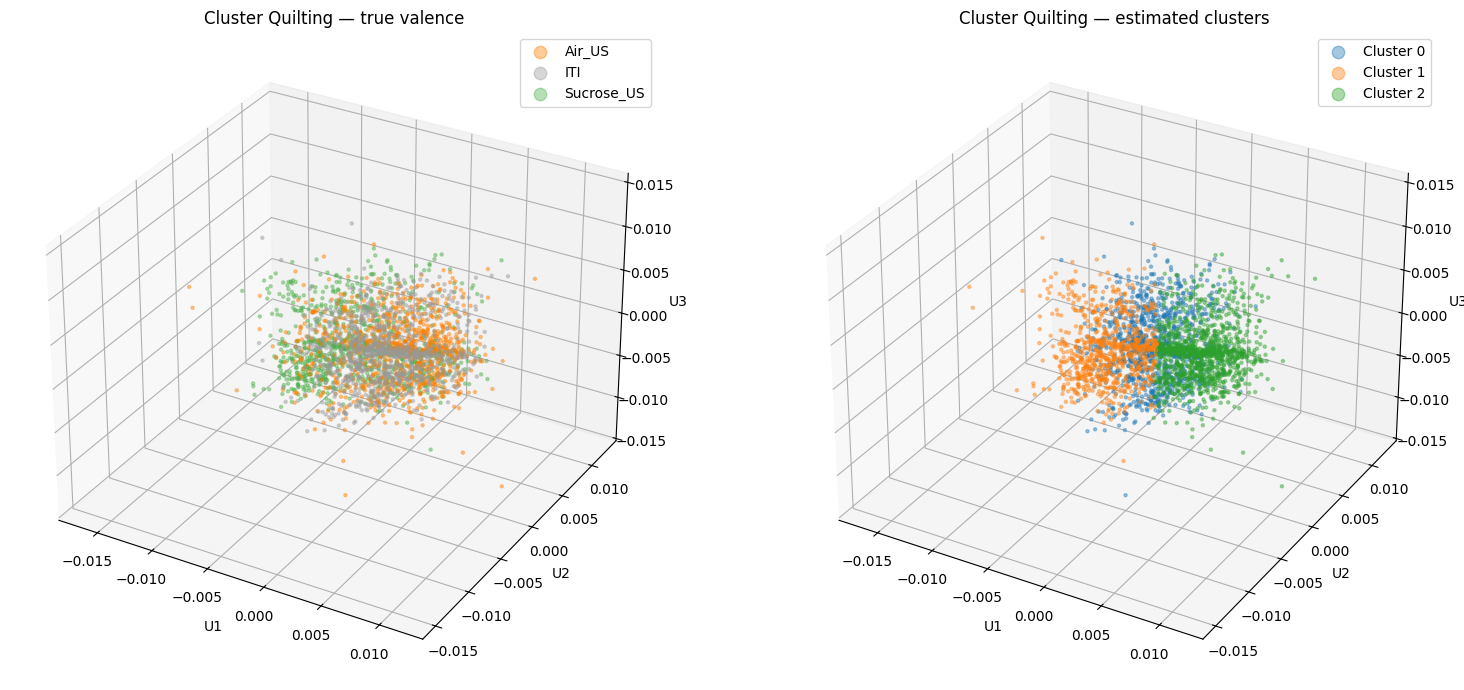


ARI = 0.1304, NMI = 0.1123


In [7]:
# Subsample for plotting
rng = np.random.default_rng(42)
n_per_cat = 1000
sample_idx = []
for cat in categories:
    cat_idx = np.where(valence_global == cat)[0]
    chosen = rng.choice(cat_idx, size=min(n_per_cat, len(cat_idx)), replace=False)
    sample_idx.append(chosen)
sample_idx = np.concatenate(sample_idx)

emb_sub = U_tilde[sample_idx]
val_sub = valence_global[sample_idx]
lab_sub = labels[sample_idx]

colors = {'Air_US': '#ff7f00', 'ITI': '#999999', 'Sucrose_US': '#4daf4a'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         subplot_kw={'projection': '3d'})

# Left: colored by true valence
for cat in categories:
    mask = val_sub == cat
    axes[0].scatter(emb_sub[mask, 0], emb_sub[mask, 1], emb_sub[mask, 2],
                    s=5, alpha=0.4, label=cat, color=colors.get(cat, '#000'))
axes[0].set_xlabel('U1'); axes[0].set_ylabel('U2'); axes[0].set_zlabel('U3')
axes[0].set_title('Cluster Quilting — true valence')
axes[0].legend(markerscale=4)

# Right: colored by k-means cluster
for k in range(K):
    mask = lab_sub == k
    axes[1].scatter(emb_sub[mask, 0], emb_sub[mask, 1], emb_sub[mask, 2],
                    s=5, alpha=0.4, label=f'Cluster {k}')
axes[1].set_xlabel('U1'); axes[1].set_ylabel('U2'); axes[1].set_zlabel('U3')
axes[1].set_title('Cluster Quilting — estimated clusters')
axes[1].legend(markerscale=4)

plt.tight_layout()
plt.savefig('cluster_quilting_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nARI = {ari:.4f}, NMI = {nmi:.4f}')

## 7. Sensitivity: Varying Rank $r$

In [8]:
print(f'{"r":>3}  {"ARI":>8}  {"NMI":>8}')
print('-' * 23)
for r_test in range(2, K + 5):
    lab_r, _ = cluster_quilting(patches, X_full, ordering, r=r_test, K=K)
    ari_r = adjusted_rand_score(valence_global, lab_r)
    nmi_r = normalized_mutual_info_score(valence_global, lab_r)
    marker = ' <--' if r_test == r else ''
    print(f'{r_test:>3}  {ari_r:>8.4f}  {nmi_r:>8.4f}{marker}')

  r       ARI       NMI
-----------------------


  2    0.0817    0.0793


  3    0.1304    0.1123 <--


  4    0.1435    0.1244


  5    0.1673    0.1539


  6    0.1758    0.1604


  7    0.1929    0.1764
